In [1]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.5 MB/s eta 0:00:00


In [2]:
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

## Import Data

In [3]:
path = untar_data(URLs.PETS)
path

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:16&lt;00:00]</div>

Path('/root/.fastai/data/oxford-iiit-pet')

In [4]:
Path.BASE_PATH = path
path

Path('.')

In [5]:
path.ls()

[Path('images'), Path('annotations')]

In [6]:
(path/'images').ls()

(#7393) [Path('images/beagle_115.jpg'), Path('images/boxer_18.jpg'), Path('images/Maine_Coon_157.jpg'), Path('images/scottish_terrier_28.jpg'), Path('images/english_setter_6.jpg'), Path('images/american_pit_bull_terrier_79.jpg'), Path('images/boxer_128.jpg'), Path('images/Persian_265.jpg'), Path('images/Maine_Coon_182.jpg'), Path('images/keeshond_89.jpg'), Path('images/chihuahua_82.jpg'), Path('images/basset_hound_5.jpg'), Path('images/english_cocker_spaniel_144.jpg'), Path('images/scottish_terrier_108.jpg'), Path('images/British_Shorthair_116.jpg'), Path('images/boxer_10.jpg'), Path('images/basset_hound_194.jpg'), Path('images/beagle_85.jpg'), Path('images/japanese_chin_87.jpg'), Path('images/pug_40.jpg'), Path('images/chihuahua_199.jpg'), Path('images/english_setter_152.jpg'), Path('images/Bengal_98.jpg'), Path('images/chihuahua_174.jpg'), Path('images/leonberger_166.jpg'), Path('images/german_shorthaired_68.jpg'), Path('images/miniature_pinscher_27.jpg'), Path('images/Ragdoll_257.jp

In [7]:
# try to extract label
f_name = (path/'images').ls()[0].name
f_name

'beagle_115.jpg'

In [8]:
# try using regex
re.findall(r'(.+)_\d+.jpg$', f_name)

['beagle']

In [9]:
# enable mixed-precision training
from fastai.callback.fp16 import *

## Objective: improve upon book's classification results

The book's [published](https://github.com/fastai/fastbook/blob/master/05_pet_breeds.ipynb) best error rate is **0.054127**.

My best error rate from running the same code is **0.074425**.

### Strategy 1: Same data prep as book, different model arch

In [10]:
# prepare dataloader
pets = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(seed=42),
    get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'), 'name'),
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(size=224, min_scale=0.75),
)

pets.summary(path/'images')

Setting-up type transforms pipelines
Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}


Building one sample
  Pipeline: PILBase.create
    starting from
      /root/.fastai/data/oxford-iiit-pet/images/basset_hound_43.jpg
    applying PILBase.create gives
      PILImage mode=RGB size=333x500
  Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

    starting from
      /root/.fastai/data/oxford-iiit-pet/images/basset_hound_43.jpg
    applying partial gives
      basset_hound
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
 gives
      TensorCategory(14)

Final sample: (PILImage mode=RGB size=333x500, TensorCategory(14))


Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

Setting up 

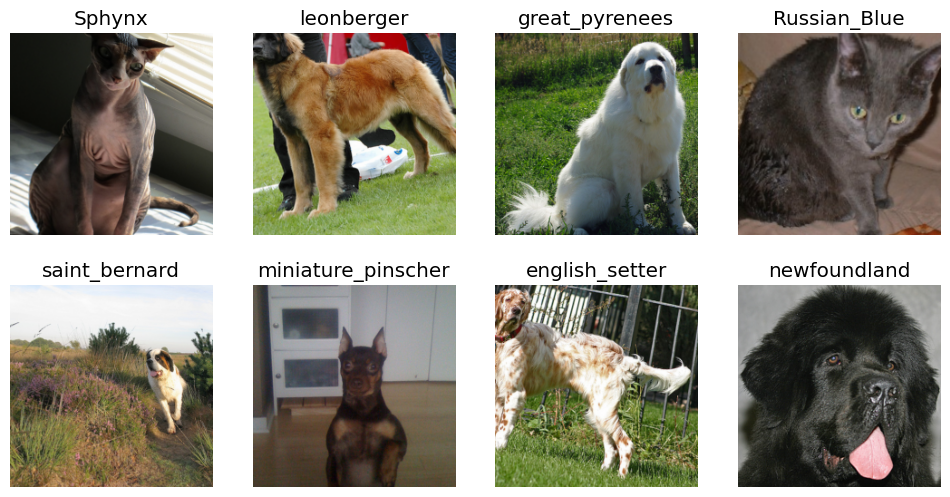

In [11]:
dls = pets.dataloaders(path/'images')
dls.show_batch(nrows=2, ncols=4)

#### Arch 1: ConvNeXt-tiny

In [12]:
import timm

In [13]:
timm.list_models('convnext*')

['convnext_atto',
 'convnext_atto_ols',
 'convnext_atto_rms',
 'convnext_base',
 'convnext_femto',
 'convnext_femto_ols',
 'convnext_large',
 'convnext_large_mlp',
 'convnext_nano',
 'convnext_nano_ols',
 'convnext_pico',
 'convnext_pico_ols',
 'convnext_small',
 'convnext_tiny',
 'convnext_tiny_hnf',
 'convnext_xlarge',
 'convnext_xxlarge',
 'convnext_zepto_rms',
 'convnext_zepto_rms_ols',
 'convnextv2_atto',
 'convnextv2_base',
 'convnextv2_femto',
 'convnextv2_huge',
 'convnextv2_large',
 'convnextv2_nano',
 'convnextv2_pico',
 'convnextv2_small',
 'convnextv2_tiny']

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

<div></div>

LR min: 1.00e-02; LR steep: 1.20e-03


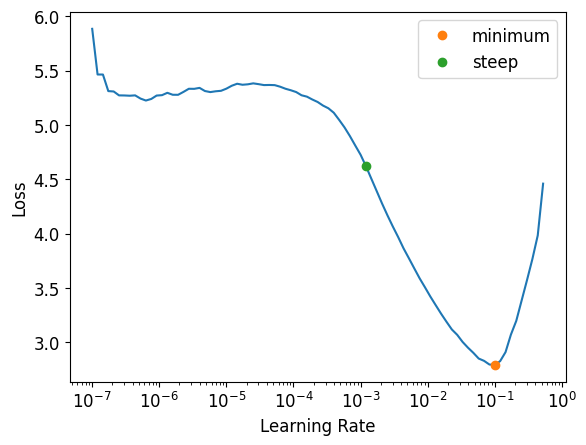

In [14]:
learn = vision_learner(dls, 'convnext_tiny', metrics=error_rate).to_fp16()
lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
print(f'LR min: {lr_min:.2e}; LR steep: {lr_steep:.2e}')

In [15]:
learn.fine_tune(12, freeze_epochs=3)

epoch,train_loss,valid_loss,error_rate,time
0,1.636305,0.264887,0.090663,00:35
1,0.515846,0.223517,0.069689,00:33
2,0.303014,0.206355,0.064953,00:33


epoch,train_loss,valid_loss,error_rate,time
0,0.158949,0.173342,0.056157,00:45
1,0.159550,0.180465,0.052097,00:40
2,0.148787,0.179360,0.051421,00:41
3,0.119864,0.180865,0.046685,00:41
4,0.106730,0.204013,0.056157,00:41
5,0.071462,0.179168,0.049391,00:41
6,0.057165,0.194258,0.046685,00:41
7,0.042470,0.190284,0.046008,00:41
8,0.035632,0.188321,0.048714,00:41
9,0.020908,0.181533,0.043302,00:41


Better results already! Let's try a deeper ConvNeXt model.

#### Arch 2: ConvNeXt-small

This model is bigger and significantly increases the training time, so I'm including a screenshot of the run I did and its results, rather than leaving the code here and blocking the notebook for more than an hour when it's run:

```python
learn = vision_learner(dls, 'convnext_small', metrics=error_rate)
learn.fine_tune(12, freeze_epochs=3)
```

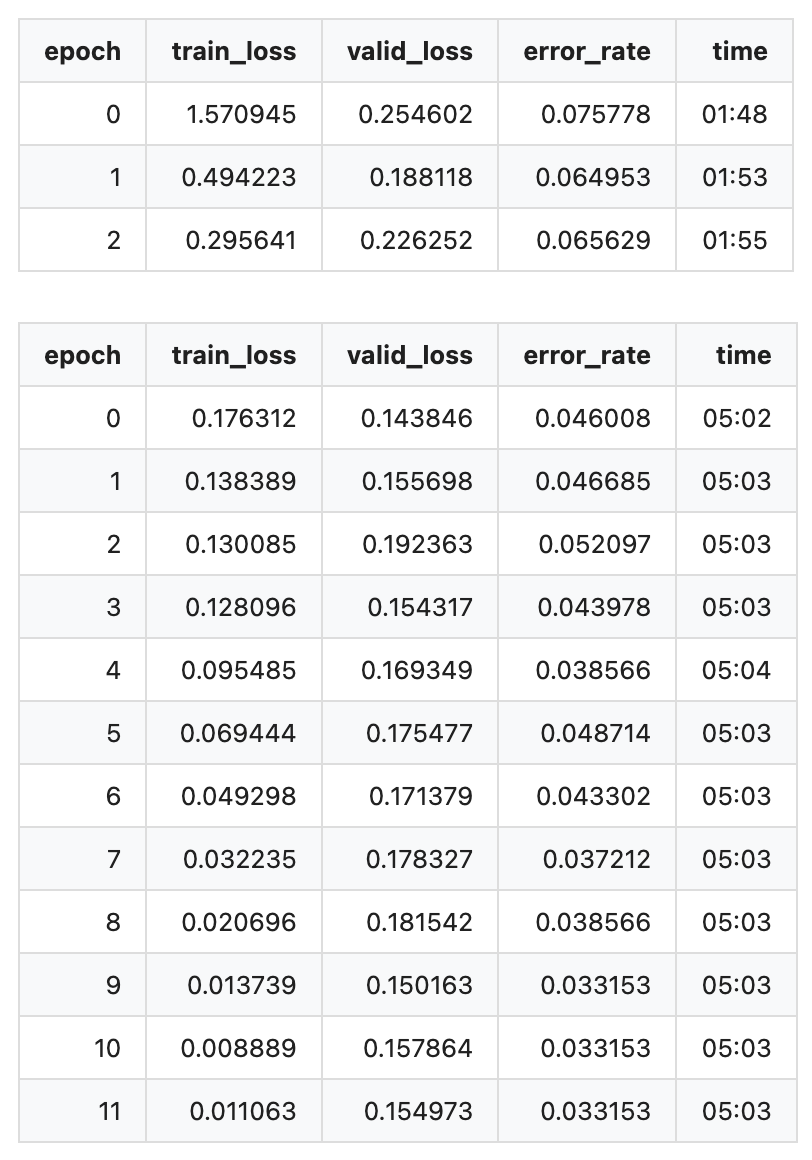

## Strategy 2: more batch transforms

Use more options of `aug_transforms` and train with the previous model arch.

In [16]:
pets1 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(seed=42),
    get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'), 'name'),
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(size=224, min_scale=0.5, mult=2, flip_vert=True),
)

pets1.summary(path/'images')

Setting-up type transforms pipelines
Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}


Building one sample
  Pipeline: PILBase.create
    starting from
      /root/.fastai/data/oxford-iiit-pet/images/basset_hound_43.jpg
    applying PILBase.create gives
      PILImage mode=RGB size=333x500
  Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

    starting from
      /root/.fastai/data/oxford-iiit-pet/images/basset_hound_43.jpg
    applying partial gives
      basset_hound
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
 gives
      TensorCategory(14)

Final sample: (PILImage mode=RGB size=333x500, TensorCategory(14))


Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

Setting up 

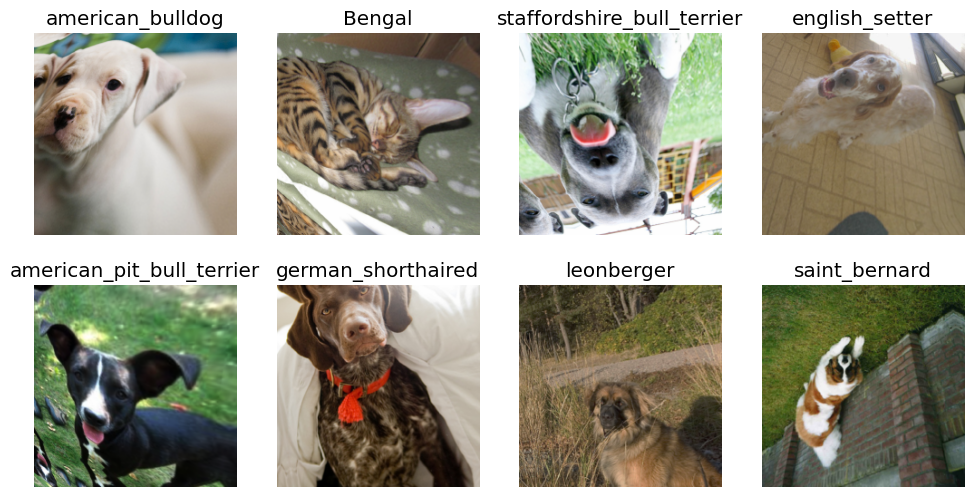

In [17]:
dls1 = pets1.dataloaders(path/'images')
dls1.show_batch(nrows=2, ncols=4)

In [18]:
learn1 = vision_learner(dls1, resnet34, metrics=error_rate)
learn1.fine_tune(12, freeze_epochs=3)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 212MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,3.342766,0.758927,0.216509,00:35
1,1.615265,0.339658,0.112314,00:34
2,1.078018,0.287682,0.092016,00:35


epoch,train_loss,valid_loss,error_rate,time
0,0.763143,0.228836,0.068336,00:43
1,0.702569,0.254342,0.079838,00:43
2,0.673585,0.307779,0.106901,00:43
3,0.595161,0.265156,0.085927,00:43
4,0.541293,0.260435,0.088633,00:42
5,0.492801,0.281904,0.089310,00:43
6,0.435111,0.245136,0.070365,00:42
7,0.356433,0.219327,0.068336,00:43
8,0.318726,0.208101,0.069012,00:42
9,0.286129,0.203382,0.065629,00:42


In [19]:
learn2 = vision_learner(dls1, resnet34, metrics=error_rate).to_fp16()
learn2.fine_tune(12, freeze_epochs=3)

epoch,train_loss,valid_loss,error_rate,time
0,3.346853,0.732417,0.205683,00:28
1,1.590755,0.309044,0.100812,00:27
2,1.086675,0.291341,0.100135,00:27


epoch,train_loss,valid_loss,error_rate,time
0,0.750970,0.249224,0.082544,00:29
1,0.655152,0.266026,0.081867,00:29
2,0.643308,0.314671,0.098782,00:29
3,0.572363,0.278210,0.096076,00:29
4,0.583724,0.289847,0.095399,00:29
5,0.517074,0.276769,0.090663,00:30
6,0.452491,0.276487,0.079838,00:30
7,0.379103,0.269847,0.084574,00:30
8,0.333869,0.218561,0.069012,00:30
9,0.286381,0.207752,0.069689,00:31
